In [1]:
import numpy as np
from config import SimulationConfig
from stimulus import StimulusGenerator
from spatializer import Spatializer
from experiment import LocalizationExperiment
from plots import ResultPlotter
from brainstem import BrainstemModel
from cochlear_nef_model import CochlearModel
import scipy.io as sio

In [3]:
data = sio.loadmat('../hrtf/2018-08-15_1000samp_ILDITDmod_correct_noitd_ex_ILD.mat')
hrir = data['allimps_reflect']

In [4]:
config = SimulationConfig()

cochlea_L = CochlearModel(
    fs=config.fs,
    n_channels=config.n_channels,
    low_freq=config.f_low,
    high_freq=config.f_high,
    neurons_per_channel=30,
)

cochlea_R = CochlearModel(
    fs=config.fs,
    n_channels=config.n_channels,
    low_freq=config.f_low,
    high_freq=config.f_high,
    neurons_per_channel=30,
)

brainstem = BrainstemModel(
    config=config,
    cochlea_L=cochlea_L,
    cochlea_R=cochlea_R,
)

Running -90.0°
Running -88.2°
Running -86.4°
Running -84.6°
Running -82.8°
Running -81.0°
Running -79.2°
Running -77.4°
Running -75.6°
Running -73.8°
Running -72.0°
Running -70.2°
Running -68.4°
Running -66.6°
Running -64.8°
Running -63.0°
Running -61.2°
Running -59.4°
Running -57.6°
Running -55.8°
Running -54.0°
Running -52.2°
Running -50.4°
Running -48.6°
Running -46.8°
Running -45.0°
Running -43.2°
Running -41.4°
Running -39.6°
Running -37.8°
Running -36.0°
Running -34.2°
Running -32.4°
Running -30.6°
Running -28.8°
Running -27.0°
Running -25.2°
Running -23.4°
Running -21.6°
Running -19.8°
Running -18.0°
Running -16.2°
Running -14.4°
Running -12.6°
Running -10.8°
Running -9.0°
Running -7.2°
Running -5.4°
Running -3.6°
Running -1.8°
Running 0.0°
Running 1.8°
Running 3.6°
Running 5.4°
Running 7.2°
Running 9.0°
Running 10.8°
Running 12.6°
Running 14.4°
Running 16.2°
Running 18.0°
Running 19.8°
Running 21.6°
Running 23.4°
Running 25.2°
Running 27.0°
Running 28.8°
Running 30.6°
Running 3

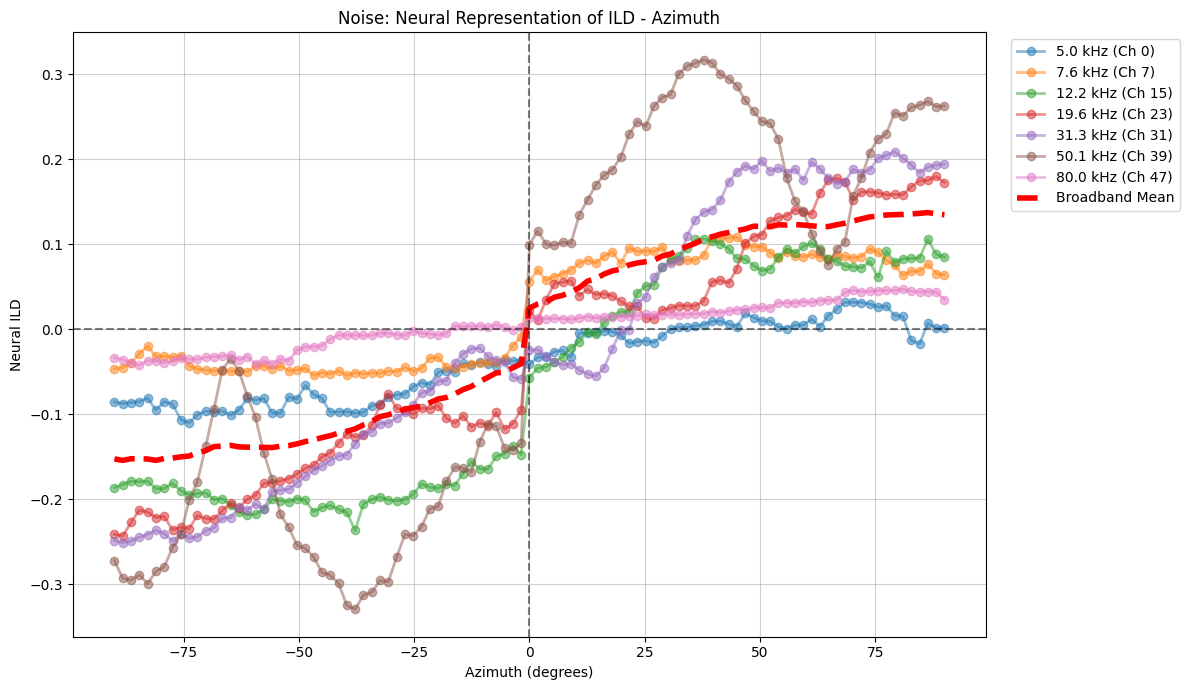

In [5]:
generator = StimulusGenerator(config)
sound = generator.generate_noise(seed=1)
spatializer = Spatializer(hrir, config)
experiment = LocalizationExperiment(
    stimulus=sound,
    spatializer=spatializer,
    cochlea_L=cochlea_L,
    cochlea_R=cochlea_R,
    brainstem=brainstem,
)
angles = np.linspace(-90,90,101)
results = experiment.run(angles)
ResultPlotter.plot_neural_ild(
    angles=results["angles"],
    neural_ild=results["ild"],
    broadband=results["broadband"],
    cfs=results["cfs"],
    title="Noise: Neural Representation of ILD - Azimuth",
)